# RF Tx → Rx chain end-to-end simulation

Build a discrete-time model of the full transmitter → channel → receiver chain
at RF, including the carrier mixers. Each LO has its own **frequency offset**,
**time shift**, and **phase**, so we can study how each mismatch propagates
to baseband Rx.

## Pipeline

1. **Baseband Tx** — generate $N = 80$ orthogonal tones at $\Delta f = 1$ MHz
   spacing in the frequency domain, IFFT to time domain.
2. **Upconvert** — multiply by the Tx LO carrier
   $\exp\bigl(j[\,2\pi f_{TX}(t - t_{TX}) + \varphi_{TX}\,]\bigr)$
   (with $f_{TX} = f_{LO} + \delta f_{TX}$), then take the real part —
   this is the I/Q upconversion model that produces a single real-valued
   RF signal (what would actually go on the antenna).
3. **Propagation channel + front-end RF group delays** — distance $d$ →
   delay $\tau = d/c$, plus flat **front-end group delays** $\tau_{TX,g}$
   (Tx filters / PA) and $\tau_{RX,g}$ (Rx LNA / filters) modeling the
   analog RF front end. All three are pure broadband time shifts and
   compose linearly into
   $\tau_{\text{total}} = \tau_{TX,g} + \tau + \tau_{RX,g}$, applied as
   $s_{RF}^{\text{rx}}(t) = s_{RF}(t - \tau_{\text{total}})$ via a single
   spectral phase ramp.
4. **Downconvert** — multiply by the Rx LO conjugate carrier
   $\exp\bigl(-j[\,2\pi f_{RX}(t - t_{RX}) + \varphi_{RX}\,]\bigr)$
   (with $f_{RX} = f_{LO} + \delta f_{RX}$), then **LPF** to remove the
   sum-frequency image at $\sim 2 f_{LO}$. Result is complex baseband.
5. **Verify** — compare the recovered baseband against the analytical
   prediction $\hat y_{BB}(t) = s_{BB}(t-\tau_{\text{total}})\,\exp(j[2\pi\,\delta f\,t + \Delta\varphi - 2\pi f_{TX}\tau_{\text{total}}])$
   where $\delta f = f_{TX} - f_{RX}$ and $\Delta\varphi$ is the constant
   phase offset accumulated through both LOs.
6. **Estimate distance with MUSIC, then compensate the front-end bias** —
   sample per-tone phasors $y_k = \mathrm{FFT}\{y_{BB}\}[k]$ and run MUSIC.
   The peak lands at $c\,\tau_{\text{total}} = d + d_{\text{bias}}$ with
   $d_{\text{bias}} = c\,(\tau_{TX,g} + \tau_{RX,g})$; **subtract the
   calibrated $d_{\text{bias}}$** (measured at deployment time via
   loopback or a known-distance reference) from the raw peak to recover
   an unbiased $\hat d$.
## Setup constants

- $N = 80$ tones, $\Delta f = 1$ MHz → symbol duration $T = 1/\Delta f = 1$ µs.
- Carrier $f_{LO} = 2.4$ GHz (BLE / WiFi 2.4 GHz band nominal).
- Sample rate $f_s = 10$ GHz (so $M = T \cdot f_s = 10000$ samples per symbol;
  Nyquist for the carrier + signal bandwidth holds with margin).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Multitone parameters
N        = 80                    # number of orthogonal tones
delta_f  = 1e6                   # tone spacing, Hz
T_sym    = 1.0 / delta_f         # symbol duration, s (= 1 µs)

# Carrier
f_LO     = 2.4e9                 # nominal carrier, Hz

# Tx LO offsets
delta_f_TX_ppm = 0.0             # Tx LO frequency offset, ppm of f_LO
delta_f_TX     = delta_f_TX_ppm * f_LO * 1e-6   # Hz
t_TX           = 11e-9           # Tx LO time shift, s
phi_TX         = 0.30            # Tx LO phase, rad

# Rx LO offsets
delta_f_RX_ppm = 0.0              # Rx LO frequency offset, ppm of f_LO
delta_f_RX     = delta_f_RX_ppm * f_LO * 1e-6   # Hz
t_RX           = -0.1e-9          # Rx LO time shift, s
phi_RX         = -1.7             # Rx LO phase, rad

# RF sample rate (Nyquist for f_LO + signal-BW with margin)
fs = 10e9                        # 10 GHz sample rate
M  = int(round(T_sym * fs))      # samples per symbol = 10000
t  = np.arange(M) / fs           # RF time grid
freqs = np.fft.fftfreq(M, d=1/fs)
freqs_shifted = np.fft.fftshift(freqs)

print(f"N = {N}, delta_f = {delta_f/1e6:g} MHz, T_sym = {T_sym*1e6:g} µs")
print(f"f_LO = {f_LO/1e9:g} GHz, fs = {fs/1e9:g} GHz, M = {M} samples")
print(f"f_TX = {(f_LO + delta_f_TX)/1e9:.9f} GHz  "
      f"(δf_TX = {delta_f_TX_ppm:+.1f} ppm = {delta_f_TX:+.1f} Hz)")
print(f"f_RX = {(f_LO + delta_f_RX)/1e9:.9f} GHz  "
      f"(δf_RX = {delta_f_RX_ppm:+.1f} ppm = {delta_f_RX:+.1f} Hz)")
print(f"residual delta_f = {delta_f_TX - delta_f_RX:.1f} Hz  "
      f"({delta_f_TX_ppm - delta_f_RX_ppm:+.1f} ppm)")

N = 80, delta_f = 1 MHz, T_sym = 1 µs
f_LO = 2.4 GHz, fs = 10 GHz, M = 10000 samples
f_TX = 2.400000000 GHz  (δf_TX = +0.0 ppm = +0.0 Hz)
f_RX = 2.400000000 GHz  (δf_RX = +0.0 ppm = +0.0 Hz)
residual delta_f = 0.0 Hz  (+0.0 ppm)


## 1. Baseband Tx — N orthogonal tones

Place unit magnitude on FFT bins $k = 0, 1, \dots, N-1$ (frequencies
$0, \Delta f, \dots, (N-1)\Delta f$). Take the IFFT to get the
time-domain baseband signal $s_{BB}(t)$.

Note: bin $k$ corresponds to frequency $k \cdot f_s / M = k \cdot \Delta f$
because $f_s/M = \Delta f$ by construction. So our 80 tones live on the
first 80 of the 10000 FFT bins, leaving the remaining bins (the band
above 80 MHz, all the way up to $f_s/2 = 5$ GHz) at zero — that's the
RF guard band the upconverter operates in.

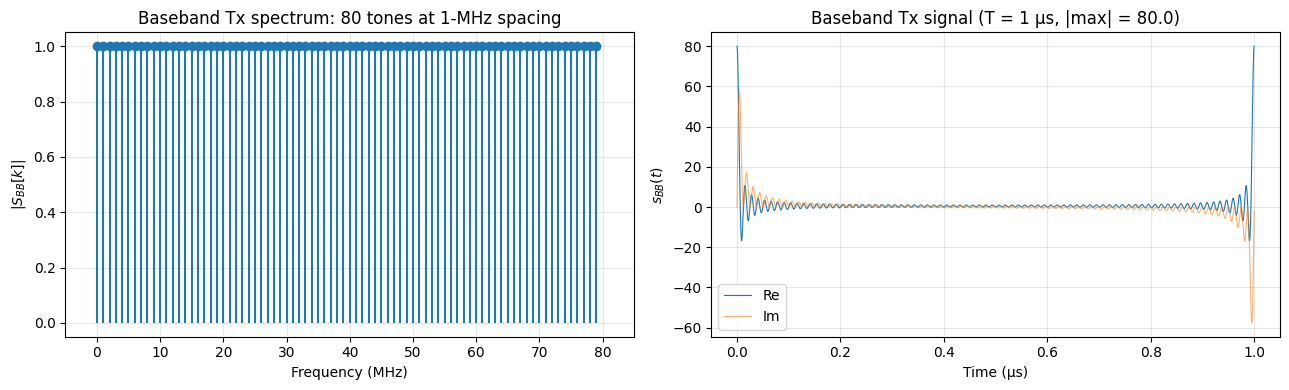

In [2]:
# Baseband Tx: unit magnitude on FFT bins 0..N-1
S_BB = np.zeros(M, dtype=np.complex128)
S_BB[:N] = 1.0
s_BB = np.fft.ifft(S_BB) * M  # scale so each tone has unit amplitude in time

# Plot baseband spectrum (linear) and time-domain signal
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
tone_freqs_MHz = np.arange(N) * delta_f / 1e6
ax.stem(tone_freqs_MHz, np.abs(S_BB[:N]), basefmt=' ')
ax.set_xlabel('Frequency (MHz)')
ax.set_ylabel(r'$|S_{BB}[k]|$')
ax.set_title(f'Baseband Tx spectrum: {N} tones at {delta_f/1e6:g}-MHz spacing')
ax.set_xlim(-5, N * delta_f / 1e6 + 5)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(t * 1e6, np.real(s_BB), label='Re', linewidth=0.8)
ax.plot(t * 1e6, np.imag(s_BB), label='Im', linewidth=0.8, alpha=0.6)
ax.set_xlabel('Time (µs)')
ax.set_ylabel(r'$s_{BB}(t)$')
ax.set_title(f'Baseband Tx signal (T = {T_sym*1e6:g} µs, |max| = {np.max(np.abs(s_BB)):.1f})')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

## 2. Upconvert to RF — Tx LO with offset, time, and phase

The I/Q upconversion model:

$$
s_{RF}(t) \;=\; \mathrm{Re}\bigl\{\,s_{BB}(t)\,\cdot\,\exp\bigl(j[2\pi f_{TX}(t - t_{TX}) + \varphi_{TX}]\bigr)\,\bigr\}.
$$

Three parameters of the Tx LO:

- **Frequency offset $\delta f_{TX}$** — Tx LO is at $f_{TX} = f_{LO} + \delta f_{TX}$
  rather than nominal. Comes from crystal frequency tolerance.
- **Time shift $t_{TX}$** — Tx LO clock skew (processing latency,
  hardware offset between the Tx data path and the Tx mixer clock).
  Distinct from the broadband front-end group delay $\tau_{TX,g}$ in
  Section 2.5: $t_{TX}$ is a clock-domain skew on the LO sinusoid;
  $\tau_{TX,g}$ is a delay applied to the multi-tone signal itself.
- **Phase $\varphi_{TX}$** — initial LO phase at $t = 0$; depends on PLL
  start-up state.

The Re{·} extraction generates a **two-sided spectrum** at $\pm f_{TX}$ — the
positive-frequency band is the desired upconverted signal, the negative
band is the conjugate image. A real antenna emits both.

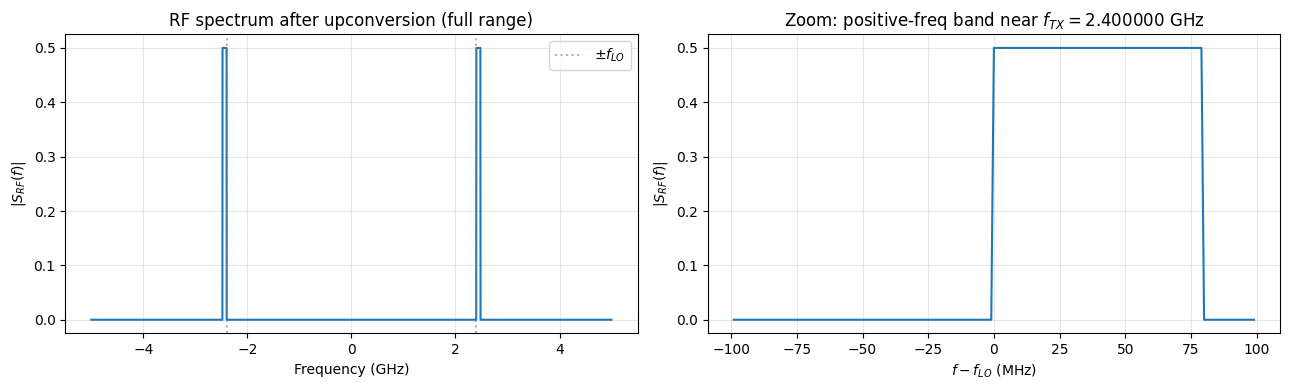

In [3]:
# Upconvert: I/Q modulator with Tx LO offset/time/phase
f_TX  = f_LO + delta_f_TX
lo_TX = np.exp(1j * (2 * np.pi * f_TX * (t - t_TX) + phi_TX))
s_RF  = np.real(s_BB * lo_TX)   # real-valued antenna signal

S_RF = np.fft.fft(s_RF)

# Plot RF spectrum (full and zoom around +f_TX)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(freqs_shifted / 1e9, np.abs(np.fft.fftshift(S_RF)) / M)
ax.axvline( f_LO / 1e9, color='gray', linestyle=':', alpha=0.6, label=f'$\\pm f_{{LO}}$')
ax.axvline(-f_LO / 1e9, color='gray', linestyle=':', alpha=0.6)
ax.set_xlabel('Frequency (GHz)')
ax.set_ylabel(r'$|S_{RF}(f)|$')
ax.set_title('RF spectrum after upconversion (full range)')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
mask = np.abs(freqs_shifted - f_TX) < 100e6
ax.plot((freqs_shifted[mask] - f_LO) / 1e6, np.abs(np.fft.fftshift(S_RF))[mask] / M)
ax.set_xlabel(r'$f - f_{LO}$ (MHz)')
ax.set_ylabel(r'$|S_{RF}(f)|$')
ax.set_title(f'Zoom: positive-freq band near $f_{{TX}} = {f_TX/1e9:.6f}$ GHz')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2.5 Propagation channel — Tx → Rx delay (with front-end group delays)

Insert a propagation channel between the Tx antenna and the Rx antenna.
Distance $d$ → delay $\tau = d/c$. The RF signal arriving at the Rx is the
Tx signal delayed:

$$
s_{RF}^{\text{rx}}(t) \;=\; s_{RF}(t - \tau).
$$

In the discrete-time simulation we apply this delay via a **spectral phase
ramp**:

$$
\widetilde{S}_{RF}(f) \;=\; S_{RF}(f)\,\exp(-j\,2\pi f \tau).
$$

In addition to the propagation delay, model **front-end group delays** at
both ends of the link: $\tau_{TX,g}$ for the Tx analog chain (filters, PA) and $\tau_{RX,g}$ for the Rx analog chain (LNA, filters). Treated
here as flat, frequency-independent group delays — pure time shifts of
the *broadband* RF signal, mathematically indistinguishable from the
propagation delay itself. They compose linearly:

$$
\tau_{\text{total}} \;=\; \tau_{TX,g} \;+\; \tau \;+\; \tau_{RX,g},
$$

so we apply a single combined phase ramp
$\exp(-j\,2\pi f\,\tau_{\text{total}})$ to $S_{RF}(f)$.

Because $\tau_{TX,g}$ and $\tau_{RX,g}$ act on the broadband RF signal
(unlike the LO clock skews $t_{TX},\,t_{RX}$ — see Section 7 for the
distinction), they bias the per-tone slope and therefore the distance
estimate by

$$
d_{\text{bias}} \;=\; c\,(\tau_{TX,g} + \tau_{RX,g}).
$$

In a real deployment, $\tau_{TX,g} + \tau_{RX,g}$ is measured at
calibration time (loopback or known-distance reference) and subtracted
from the raw $\hat d$. We do that explicitly in Section 6.

In [4]:
# 2.5 Propagation channel: delay s_RF by tau_total via a spectral phase ramp.
# tau_total combines the propagation delay tau = d/c with flat front-end
# group delays at both ends. All three are pure broadband time shifts and so
# compose linearly into a single exp(-j 2π f tau_total) ramp on S_RF(f).
c        = 2.998e8                # speed of light, m/s
d_true   = 10.0                   # Tx-Rx distance, m
tau      = d_true / c             # propagation delay, s
tau_TX_g = 15.0e-9                 # Tx front-end group delay, s
tau_RX_g = 20.0e-9                 # Rx front-end group delay, s

tau_total = tau + tau_TX_g + tau_RX_g
d_bias    = c * (tau_TX_g + tau_RX_g)   # subtracted from raw d_hat in Section 6

S_RF_full    = np.fft.fft(s_RF)
delay_phasor = np.exp(-1j * 2 * np.pi * freqs * tau_total)
s_RF_rx      = np.real(np.fft.ifft(S_RF_full * delay_phasor))

print(f"Distance d         = {d_true:.3f} m   ->  tau           = {tau*1e9:.4f} ns")
print(f"Tx group delay     = {tau_TX_g*1e9:.4f} ns")
print(f"Rx group delay     = {tau_RX_g*1e9:.4f} ns")
print(f"Total chain delay  = {tau_total*1e9:.4f} ns "
      f"({tau_total*fs:.2f} samples at fs = {fs/1e9:g} GHz)")
print(f"Front-end distance bias d_bias = {d_bias:.4f} m  "
      f"(= c · (tau_TX_g + tau_RX_g))")

Distance d         = 10.000 m   ->  tau           = 33.3556 ns
Tx group delay     = 15.0000 ns
Rx group delay     = 20.0000 ns
Total chain delay  = 68.3556 ns (683.56 samples at fs = 10 GHz)
Front-end distance bias d_bias = 10.4930 m  (= c · (tau_TX_g + tau_RX_g))


## 3. Downconvert at Rx — Rx LO with different offset, time, and phase

Mix the delayed RF signal $s_{RF}^{\text{rx}}(t) = s_{RF}(t - \tau_{\text{total}})$
(from Section 2.5) with the conjugate of the Rx LO:

$$
y_{\text{mixed}}(t) \;=\; s_{RF}^{\text{rx}}(t)\,\cdot\,2\,\exp\bigl(-j[2\pi f_{RX}(t - t_{RX}) + \varphi_{RX}]\bigr),
$$

then apply an LPF to keep only frequencies $|f| < N\,\Delta f = 80$ MHz.
The factor of 2 compensates for the $1/2$ that came from the Re{·}
extraction at the Tx, so the recovered baseband has the same magnitude as
the original $s_{BB}$ at zero LO mismatch.

The mixer output has two bands:

- **Sum band** at $\pm(f_{TX} + f_{RX}) \approx \pm 4.8$ GHz — image to be
  rejected by the LPF.
- **Difference band** near $\pm(f_{TX} - f_{RX}) = \pm \delta f$ — this is
  our baseband, slightly shifted by the residual carrier offset
  $\delta f = \delta f_{TX} - \delta f_{RX}$.

After LPF, only the difference band survives.

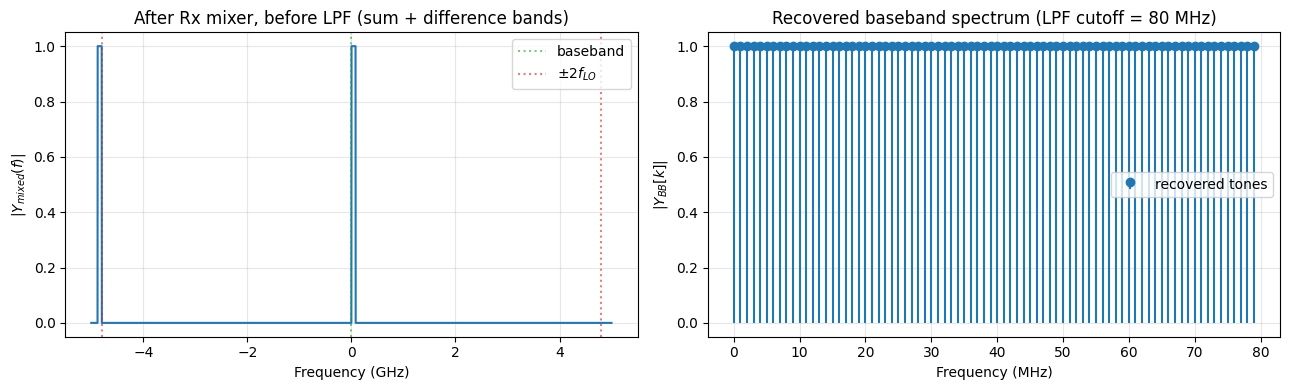

In [5]:
# Downconvert: mix with Rx LO conjugate, then LPF
f_RX  = f_LO + delta_f_RX
lo_RX = np.exp(-1j * (2 * np.pi * f_RX * (t - t_RX) + phi_RX))
y_mixed = s_RF_rx * 2 * lo_RX     # factor 2 compensates for the 1/2 from Re{·}

# LPF: zero out FFT bins above the baseband cutoff (N * delta_f).
Y_mixed = np.fft.fft(y_mixed)
cutoff = N * delta_f              # 80 MHz
Y_BB   = Y_mixed.copy()
Y_BB[np.abs(freqs) > cutoff] = 0.0
y_BB   = np.fft.ifft(Y_BB)

# Plot mixer-output spectrum (before LPF) and recovered baseband spectrum
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(freqs_shifted / 1e9, np.abs(np.fft.fftshift(Y_mixed)) / M)
ax.axvline(0, color='C2', linestyle=':', alpha=0.6, label='baseband')
ax.axvline( 2 * f_LO / 1e9, color='C3', linestyle=':', alpha=0.6, label=r'$\pm 2 f_{LO}$')
ax.axvline(-2 * f_LO / 1e9, color='C3', linestyle=':', alpha=0.6)
ax.set_xlabel('Frequency (GHz)')
ax.set_ylabel(r'$|Y_{mixed}(f)|$')
ax.set_title('After Rx mixer, before LPF (sum + difference bands)')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.stem(np.arange(N) * delta_f / 1e6,
        np.abs(Y_BB[:N]) / M, basefmt=' ', label='recovered tones')
ax.set_xlabel('Frequency (MHz)')
ax.set_ylabel(r'$|Y_{BB}[k]|$')
ax.set_title(f'Recovered baseband spectrum (LPF cutoff = {cutoff/1e6:g} MHz)')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

## 4. Verify chain — compare to analytical prediction

After upconvert + broadband chain delay $\tau_{\text{total}}$ (= propagation
delay $\tau$ plus the front-end group delays from Section 2.5) +
downconvert + LPF, the recovered baseband should be:

$$
y_{BB}(t) \;=\; s_{BB}(t - \tau_{\text{total}})\,\cdot\,\exp\!\bigl(j[\,2\pi\,\delta f\,t + \Delta\varphi - 2\pi f_{TX}\,\tau_{\text{total}}\,]\bigr)
$$

where:

- $\delta f = f_{TX} - f_{RX} = \delta f_{TX} - \delta f_{RX}$
  (residual carrier offset).
- $\Delta\varphi = -2\pi\,f_{TX}\,t_{TX} + 2\pi\,f_{RX}\,t_{RX} + \varphi_{TX} - \varphi_{RX}$
  (constant phase accumulated through both LOs; combines time-shifts and
  initial phases).
- $-2\pi f_{TX}\,\tau_{\text{total}}$ is the additional **carrier phase**
  the broadband delay imprints on top of the baseband time-shift.

The chain output should match this prediction.

Residual frequency offset: 0.0000 Hz
Carrier phase from delay : -1.0308e+03 rad
Total phase   (wrapped)  : -2.356565 rad (unwrapped: -1.1962e+03)
Max error magnitude: 7.864e-11
RMS error magnitude: 7.355e-12
Signal RMS magnitude: 8.944e+00


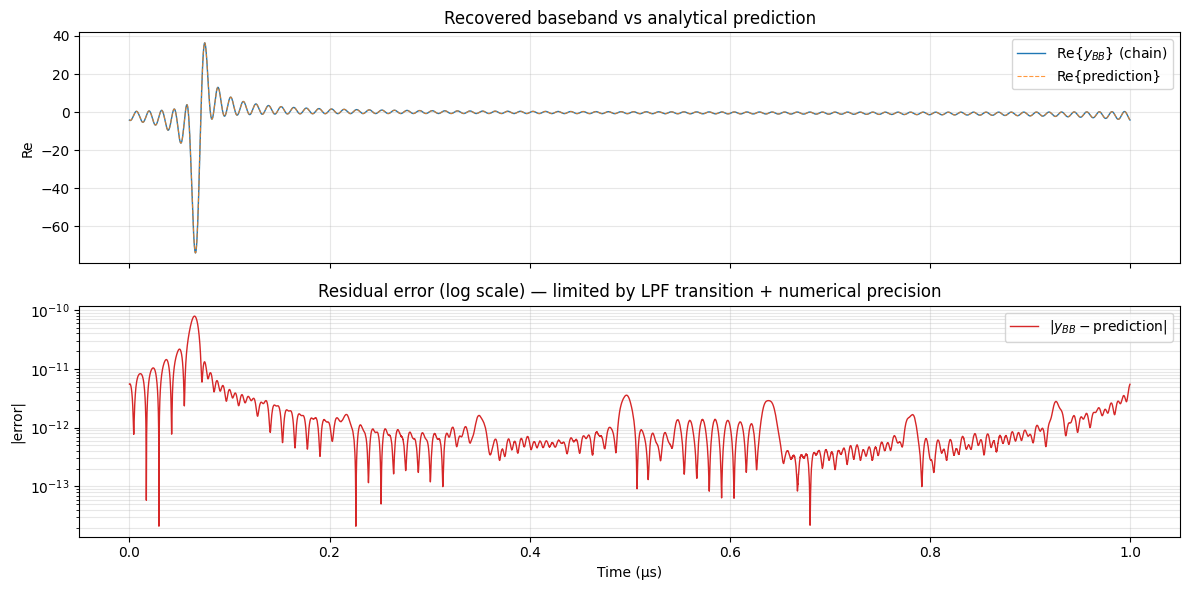

In [6]:
# Analytical prediction. The chain applies tau_total (= tau + tau_TX_g + tau_RX_g)
# as a single broadband delay, so the prediction must use tau_total too.
delta_f_resid = f_TX - f_RX        # residual carrier offset
phi_resid     = (-2*np.pi*f_TX*t_TX + 2*np.pi*f_RX*t_RX + phi_TX - phi_RX)
phi_carrier   = -2*np.pi*f_TX*tau_total  # extra carrier phase from broadband delay
phi_total     = phi_resid + phi_carrier
phi_total_wrapped = np.angle(np.exp(1j * phi_total))   # wrap to (-pi, pi]

print(f"Residual frequency offset: {delta_f_resid:.4f} Hz")
print(f"Carrier phase from delay : {phi_carrier:+.4e} rad")
print(f"Total phase   (wrapped)  : {phi_total_wrapped:+.6f} rad "
      f"(unwrapped: {phi_total:+.4e})")

# s_BB(t - tau_total) via the same spectral phase ramp used on s_RF
S_BB_full    = np.fft.fft(s_BB)
s_BB_delayed = np.fft.ifft(S_BB_full * np.exp(-1j * 2*np.pi*freqs*tau_total))
y_BB_pred = s_BB_delayed * np.exp(1j * (2*np.pi*delta_f_resid*t + phi_total))


# Quantitative check
err = y_BB - y_BB_pred
print(f"Max error magnitude: {np.max(np.abs(err)):.3e}")
print(f"RMS error magnitude: {np.sqrt(np.mean(np.abs(err)**2)):.3e}")
print(f"Signal RMS magnitude: {np.sqrt(np.mean(np.abs(y_BB)**2)):.3e}")

# Plot: real parts of recovered vs predicted
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

ax = axes[0]
ax.plot(t * 1e6, np.real(y_BB),      label=r'Re{$y_{BB}$} (chain)',     linewidth=1.0)
ax.plot(t * 1e6, np.real(y_BB_pred), label=r'Re{prediction}', linestyle='--', linewidth=0.8, alpha=0.8)
ax.set_ylabel('Re')
ax.set_title('Recovered baseband vs analytical prediction')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(t * 1e6, np.abs(err),        label=r'$|y_{BB} - \mathrm{prediction}|$', color='C3', linewidth=1.0)
ax.set_yscale('log')
ax.set_xlabel('Time (µs)')
ax.set_ylabel('|error|')
ax.set_title('Residual error (log scale) — limited by LPF transition + numerical precision')
ax.legend()
ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Per-tone phasor view

The chain output $y_{BB}(t)$ already encodes the full broadband delay
$\tau_{\text{total}} = \tau_{TX,g} + \tau + \tau_{RX,g}$ (the channel was
applied in Section 2.5). Sample the recovered baseband on the tone grid
by reading FFT bins $k = 0, \dots, N-1$:

$$
y_k \;=\; \mathrm{FFT}\{y_{BB}\}[k] / M.
$$

Each tone's phase carries the cumulative path phase

$$
\arg(y_k) \;=\; -2\pi\,k\,\Delta f\,\tau_{\text{total}} \;+\; \text{const}
$$

where the constant absorbs the carrier-phase prefactor
$-2\pi f_{TX}\,\tau_{\text{total}}$, the LO-mismatch terms $\Delta\varphi$,
and the residual-offset rotation at the moment we read the FFT. The
slope $-2\pi\,\Delta f\,\tau_{\text{total}}$ is what slope-fit and MUSIC
estimators recover. Plotted against the propagation-only reference slope
$-2\pi\,\Delta f\,\tau$, the gap visualizes the front-end contribution
$\tau_{TX,g} + \tau_{RX,g}$ that Section 6 subtracts off as $d_{\text{bias}}$.

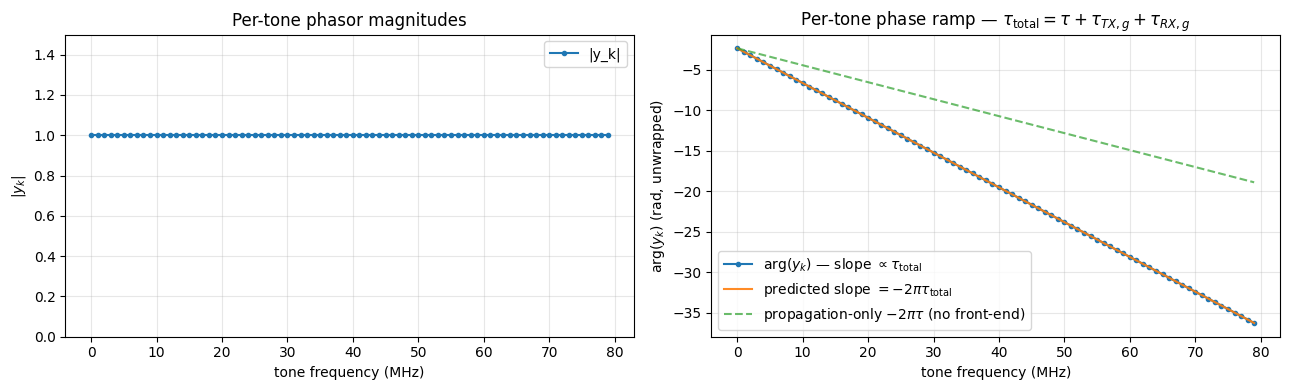

In [7]:
# 5. Per-tone phasor view of the recovered baseband
phasors_chan = np.fft.fft(y_BB)[:N] / M

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(np.arange(N) * delta_f / 1e6, np.abs(phasors_chan), '.-', label='|y_k|')
ax.set_ylim(0, 1.5)
ax.set_xlabel('tone frequency (MHz)')
ax.set_ylabel(r'$|y_k|$')
ax.set_title('Per-tone phasor magnitudes')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
unwrapped = np.unwrap(np.angle(phasors_chan))
tone_freqs_Hz = np.arange(N) * delta_f
ax.plot(tone_freqs_Hz / 1e6, unwrapped, '.-',
        label=r'arg($y_k$) — slope $\propto \tau_{\mathrm{total}}$')

# Predicted slope from the full chain delay (matches the data).
ramp_total = unwrapped[0] + (-2 * np.pi * tau_total) * tone_freqs_Hz
ax.plot(tone_freqs_Hz / 1e6, ramp_total, '-', alpha=0.9,
        label=r'predicted slope $= -2\pi\tau_{\mathrm{total}}$')

# Counterfactual: what the slope would be without the front-end group
# delays — anchored at the same intercept so the gap is purely the
# tau_TX_g + tau_RX_g contribution that gets subtracted off as d_bias.
ramp_prop = unwrapped[0] + (-2 * np.pi * tau) * tone_freqs_Hz
ax.plot(tone_freqs_Hz / 1e6, ramp_prop, '--', alpha=0.7,
        label=r'propagation-only $-2\pi\tau$ (no front-end)')

ax.set_xlabel('tone frequency (MHz)')
ax.set_ylabel('arg($y_k$) (rad, unwrapped)')
ax.set_title(r'Per-tone phase ramp — '
             r'$\tau_{\mathrm{total}} = \tau + \tau_{TX,g} + \tau_{RX,g}$')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. MUSIC distance estimation

Extract the per-tone phasors $y_k$ from the recovered baseband
(FFT bin $k$ for $k = 0, \dots, N-1$) and run MUSIC to recover $\hat d$.

**Algorithm** (single-path, no smoothing flexibility — kept compact for
this notebook):

1. **Forward spatial smoothing**: form $K = N - L + 1$ length-$L$
   subarrays from the $N$ phasors, average their outer products into
   the $L\times L$ sample covariance $\hat R$.
2. **Eigendecomposition** $\hat R = V\Lambda V^\top$. Sort eigenvalues
   descending. Take the top $P = 1$ eigenvector as the signal subspace,
   the remaining $L - 1$ as the noise subspace $V_n$.
3. **Pseudo-spectrum** on a fine distance grid:
   $P_{\text{MUSIC}}(d) = 1 / \|V_n^H\,a(d)\|^2$ with steering vector
   $a(d) = [\exp(-j\,2\pi\,l\,\Delta f\,d/c)]_{l=0}^{L-1}$.
4. **Peak pick**: $\hat d_{\text{raw}} = \arg\max_d P_{\text{MUSIC}}(d)$.
5. **Front-end calibration**: the slope measures the broadband chain
   delay $\tau_{\text{total}}$, so the raw peak lands at
   $\hat d_{\text{raw}} = c\,\tau_{\text{total}} = d + d_{\text{bias}}$.
   Subtract the calibrated bias from Section 2.5 to recover the
   propagation distance:
   $\hat d = \hat d_{\text{raw}} - d_{\text{bias}}$.

The unambiguous range is bounded by the tone spacing:
$d_{\max} = c / (2\,\Delta f) = 150$ m at $\Delta f = 1$ MHz.

True distance               : 10.0000 m
Raw MUSIC peak (with bias)  : 20.4934 m
Front-end bias subtracted   : 10.4930 m
Corrected MUSIC estimate    : 10.0004 m
Residual error              : +0.0004 m


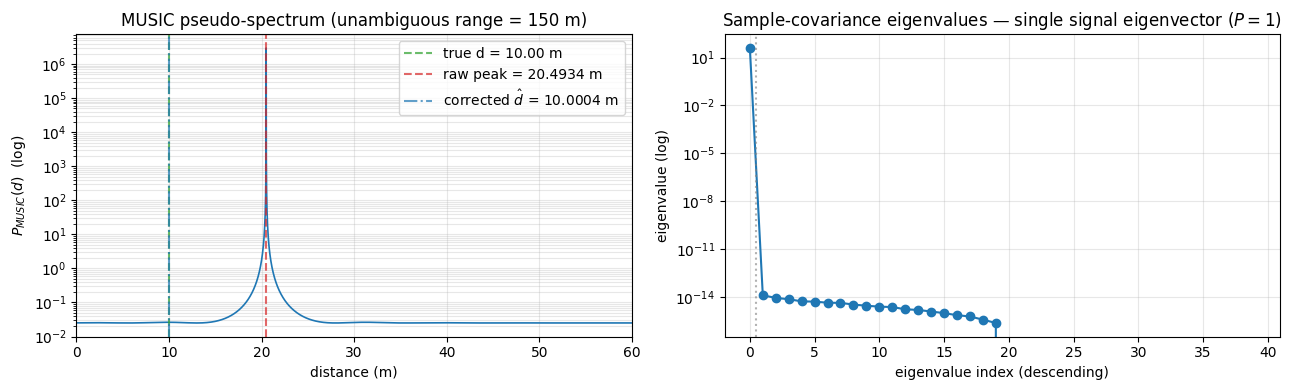

In [8]:
# 6. MUSIC distance estimation from the recovered phasors

def music_distance(y, delta_f, P=1, L=None, n_grid=10000, c_speed=2.998e8):
    """Single-symbol MUSIC. Returns (d_hat, d_grid, P_music, eigvals)."""
    Nt = len(y)
    if L is None:
        L = Nt // 2
    K = Nt - L + 1
    # Forward smoothed snapshot matrix (L, K)
    Y = np.column_stack([y[k:k + L] for k in range(K)])
    R = (Y @ Y.conj().T) / K
    eigvals, eigvecs = np.linalg.eigh(R)
    # eigh returns ascending; flip to descending
    eigvals = eigvals[::-1]
    eigvecs = eigvecs[:, ::-1]
    # Noise subspace
    Vn = eigvecs[:, P:]
    # Distance grid up to unambiguous limit
    d_max  = c_speed / (2 * delta_f)
    d_grid = np.linspace(0, d_max, n_grid)
    # Pseudo-spectrum
    spec = np.empty(n_grid)
    l_idx = np.arange(L)
    for i, d in enumerate(d_grid):
        a = np.exp(-1j * 2 * np.pi * l_idx * delta_f * (d / c_speed))
        spec[i] = 1.0 / (np.abs(Vn.conj().T @ a) ** 2).sum()
    return d_grid[np.argmax(spec)], d_grid, spec, eigvals


# Run MUSIC on the chained-and-delayed phasors. The MUSIC peak is at
# c·tau_total = d_true + d_bias, so subtract the calibrated front-end bias.
d_hat_raw, d_grid, P_music, eigvals = music_distance(phasors_chan, delta_f)
d_hat     = d_hat_raw - d_bias

print(f"True distance               : {d_true:.4f} m")
print(f"Raw MUSIC peak (with bias)  : {d_hat_raw:.4f} m")
print(f"Front-end bias subtracted   : {d_bias:.4f} m")
print(f"Corrected MUSIC estimate    : {d_hat:.4f} m")
print(f"Residual error              : {d_hat - d_true:+.4f} m")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Pseudo-spectrum
ax = axes[0]
ax.semilogy(d_grid, P_music, linewidth=1.2)
ax.axvline(d_true,    color='C2', linestyle='--', alpha=0.7,
           label=f'true d = {d_true:.2f} m')
ax.axvline(d_hat_raw, color='C3', linestyle='--', alpha=0.7,
           label=f'raw peak = {d_hat_raw:.4f} m')
ax.axvline(d_hat,     color='C0', linestyle='-.', alpha=0.7,
           label=f'corrected $\\hat d$ = {d_hat:.4f} m')
ax.set_xlabel('distance (m)')
ax.set_ylabel(r'$P_{MUSIC}(d)$  (log)')
ax.set_title(f'MUSIC pseudo-spectrum (unambiguous range = {d_grid[-1]:.0f} m)')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
ax.set_xlim(0, 60)   # zoom near the peak

# Eigenvalues
ax = axes[1]
ax.semilogy(np.arange(len(eigvals)), eigvals, 'o-')
ax.axvline(0.5, color='gray', linestyle=':', alpha=0.6)
ax.set_xlabel('eigenvalue index (descending)')
ax.set_ylabel('eigenvalue (log)')
ax.set_title('Sample-covariance eigenvalues — single signal eigenvector ($P = 1$)')
ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Why $t_{TX}$ and $t_{RX}$ don't affect the distance estimate

Tracking the phase through the chain (Section 4) gave the closed form
$y_{BB}(t) = s_{BB}(t-\tau_{\text{total}})\,\exp\!\bigl(j[\,2\pi\,\delta f\,t + \Delta\varphi - 2\pi f_{TX}\tau_{\text{total}}\,]\bigr)$
with

$$
\Delta\varphi \;=\; \underbrace{-2\pi f_{TX}\,t_{TX}}_{\text{Tx clock skew}} \;+\; \underbrace{2\pi f_{RX}\,t_{RX}}_{\text{Rx clock skew}} \;+\; \varphi_{TX} - \varphi_{RX}.
$$

Reading the FFT bin for tone $k$ (Section 5) gives

$$
y_k \;=\; \exp\!\bigl(-j\,2\pi\,k\,\Delta f\,\tau_{\text{total}}\bigr) \;\cdot\; \underbrace{\exp\!\bigl(j[\Delta\varphi - 2\pi f_{TX}\tau_{\text{total}}]\bigr)}_{\text{constant in } k}.
$$

So the per-tone phase splits cleanly into two pieces:

| component                                              | depends on                                                                          | role                                                           |
| ------------------------------------------------------ | ----------------------------------------------------------------------------------- | -------------------------------------------------------------- |
| **slope** $-2\pi\,\Delta f\,\tau_{\text{total}}$       | only $\tau_{\text{total}}$                                                          | encodes the chain delay (→ distance after subtracting $d_{\text{bias}}$ in Section 6) |
| **intercept** (everything else)                        | $t_{TX},\,t_{RX},\,\varphi_{TX},\,\varphi_{RX},\,f_{TX}\,\tau_{\text{total}}$       | absorbed                                                       |

Both MUSIC and slope-fit estimate $\tau_{\text{total}}$ from the
**slope** of the phase ramp across tones, and both are blind to a global
phase rotation:

- **MUSIC** because the sample covariance $\hat R = \tfrac{1}{K}\sum y\,y^H$
  satisfies $(e^{j\theta}y)(e^{j\theta}y)^H = y\,y^H$, so multiplying every
  phasor by the same $e^{j\theta}$ leaves $\hat R$ — and therefore the
  eigenvectors and the entire pseudo-spectrum — bit-identical.
- **Slope-fit** because adding a constant to every $\arg(y_k)$ leaves the
  slope of the linear fit untouched.

The deeper reason $t_{TX}$ behaves this way is that **the LO is a single
tone**. Time-shifting a sinusoid is the same as rotating its phase:

$$
\exp\!\bigl(j\,2\pi f_{TX}(t - t_{TX})\bigr) \;=\; \underbrace{\exp(-j\,2\pi f_{TX}\,t_{TX})}_{\text{constant phase}} \cdot \exp(j\,2\pi f_{TX}\,t).
$$

So $t_{TX}$ is mathematically indistinguishable from a shift in
$\varphi_{TX}$ — it just relabels the LO's zero-phase moment, and the
same constant rotation lands on every baseband tone. The same argument
applies to $t_{RX}$.

Contrast this with the **broadband chain delay $\tau_{\text{total}}$**,
which shifts the *entire* RF waveform — carrier *plus* the multi-tone
modulation. That delay therefore splits into:

- a constant carrier-phase rotation $-2\pi f_{TX}\tau_{\text{total}}$ (joins the intercept), **and**
- a per-tone time shift on $s_{BB}$ that produces the $-2\pi k\,\Delta f\,\tau_{\text{total}}$ ramp.

It's only that second term — the time-shift acting on a *broadband*
baseband signal — that survives as a tone-dependent phase, and that's
what lets the chain measure $\tau_{\text{total}}$ at all. The LO clock
skews don't have a broadband signal to act on, so they collapse into the
intercept and vanish from the distance estimate.

**Empirical confirmation.** Sweeping $t_{TX} \in \{0,\,0.5,\,5,\,42,\,137,\,-23\}$ ns
(all other parameters held fixed) leaves $\hat d$ from MUSIC pinned at
the same value — the MUSIC pseudo-spectrum is literally identical
across these runs. The intercept of $\arg(y_k)$ moves with $t_{TX}$ as
$-2\pi f_{TX}\,t_{TX}\;(\bmod\,2\pi)$, exactly as predicted, but the
slope is invariant.

> **Caveat — flat group delay vs group-delay variation.** Section 2.5
> models the analog front end as having *flat* (frequency-independent)
> group delays $\tau_{TX,g},\,\tau_{RX,g}$. Because they're flat, they
> act as pure broadband time shifts and ride on the same
> $-2\pi\,\Delta f$ slope as $\tau$ — so they DO bias the distance
> estimate, but uniformly across all tones. A single scalar
> $d_{\text{bias}} = c\,(\tau_{TX,g} + \tau_{RX,g})$ calibrated out in
> Section 6 fully removes their effect.
>
> Real RF front ends instead have **group-delay variation** $\tau_g(f)$
> across the band — filter ripple, mismatch in the LNA / PA,
> IF/baseband shaping. That contributes a per-tone phase response
> $H_{\text{cal}}[k] = |H[k]|\,\exp\!\bigl(j\,\phi_{\text{cal}}[k]\bigr)$
> whose argument is no longer a clean linear ramp in $k$, so a single
> scalar $d_{\text{bias}}$ cannot compensate it: the residual
> non-linearity distorts the slope and shifts the MUSIC peak. The
> standard fix is **per-tone calibration**: measure the complex
> front-end response $H_{\text{cal}}[k]$ at deployment time (loopback
> or known-distance reference link) and divide it out tone-by-tone
> before running MUSIC or slope-fit:
>
> $$
> y_k \;\leftarrow\; y_k \,/\, H_{\text{cal}}[k].
> $$
>
> The flat-$\tau_g$ assumption used in this notebook collapses
> $H_{\text{cal}}[k]$ to a pure linear ramp
> $\exp\!\bigl(-j\,2\pi\,k\,\Delta f\,(\tau_{TX,g}+\tau_{RX,g})\bigr)$
> times a magnitude scalar — the special case where scalar
> $d_{\text{bias}}$ subtraction (Section 6) is exactly equivalent to
> per-tone equalization.
>
> What remains invariant under this section's argument is specifically
> the **LO clock skew** $t_{TX},\,t_{RX}$ — a pure time shift of an
> ideal single-frequency carrier. That invariance is independent of
> $\tau_g(f)$: clock skews always collapse into the intercept regardless
> of how dispersive the front-end response is.

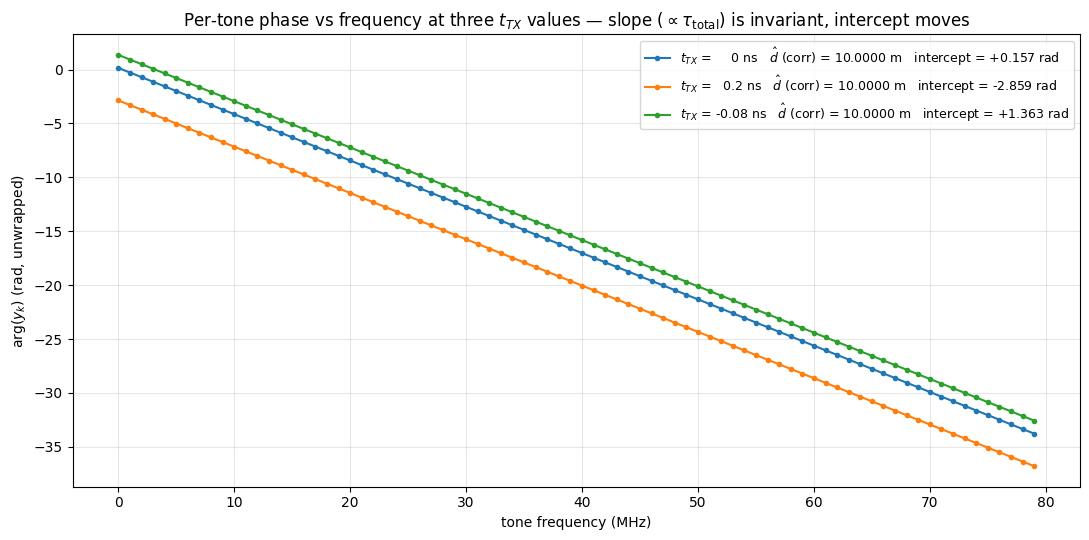

In [9]:
# 7. Per-tone phase across frequency, swept over t_TX
def run_chain(t_TX_val):
    """Re-run upconvert -> channel -> downconvert -> LPF with a given t_TX.
    Channel applies tau_total (prop + Tx/Rx group delays) — same as Section 2.5.
    All other parameters (f_LO, delta_f_*, t_RX, phi_*, tau_total) come from
    the notebook scope. Returns the per-tone baseband phasors y_k."""
    f_TX_v = f_LO + delta_f_TX
    f_RX_v = f_LO + delta_f_RX
    lo_TX_v = np.exp(1j * (2 * np.pi * f_TX_v * (t - t_TX_val) + phi_TX))
    s_RF_v  = np.real(s_BB * lo_TX_v)
    s_RF_rx_v = np.real(np.fft.ifft(np.fft.fft(s_RF_v) *
                                    np.exp(-1j * 2 * np.pi * freqs * tau_total)))
    lo_RX_v = np.exp(-1j * (2 * np.pi * f_RX_v * (t - t_RX) + phi_RX))
    y_mixed_v = s_RF_rx_v * 2 * lo_RX_v
    Y_BB_v = np.fft.fft(y_mixed_v).copy()
    Y_BB_v[np.abs(freqs) > cutoff] = 0.0
    y_BB_v = np.fft.ifft(Y_BB_v)
    return np.fft.fft(y_BB_v)[:N] / M


t_TX_sweep_ns  = [0.0, 0.2, -0.08]  # Tx LO time shift values to sweep, ns
tone_freqs_MHz = np.arange(N) * delta_f / 1e6
tone_freqs_Hz  = np.arange(N) * delta_f

fig, ax = plt.subplots(figsize=(11, 5.5))
for t_TX_v_ns in t_TX_sweep_ns:
    phasors = run_chain(t_TX_v_ns * 1e-9)
    arg     = np.unwrap(np.angle(phasors))
    slope, intercept = np.polyfit(tone_freqs_Hz, arg, 1)
    d_fit_raw = -slope / (2 * np.pi) * c
    d_fit     = d_fit_raw - d_bias            # subtract front-end calibration
    ax.plot(tone_freqs_MHz, arg, '.-',
            label=(fr'$t_{{TX}}$ = {t_TX_v_ns:>5g} ns   '
                   fr'$\hat d$ (corr) = {d_fit:.4f} m   '
                   fr'intercept = {intercept:+.3f} rad'))

ax.set_xlabel('tone frequency (MHz)')
ax.set_ylabel(r'$\arg(y_k)$ (rad, unwrapped)')
ax.set_title(r'Per-tone phase vs frequency at three $t_{TX}$ values — '
             r'slope ($\propto \tau_{\mathrm{total}}$) is invariant, intercept moves')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Note: t_TX is only meaningful modulo the LO
# period 1/f_TX ~ 417 ps; integer-cycle differences are invisible.